# Donde esta mejor "Smart" or "Ultra"?
*Dennise Lorena Celis Lugo*

# 1 Descripción del proyecto

La compañía móvil Megaline no está satisfecha al ver que muchos de sus clientes utilizan planes heredados. Quieren desarrollar un modelo que pueda analizar el comportamiento de los clientes y recomendar uno de los nuevos planes de Megaline: Smart o Ultra.

Tienes acceso a los datos de comportamiento de los suscriptores que ya se han cambiado a los planes nuevos (del proyecto del sprint de Análisis estadístico de datos). Para esta tarea de clasificación debes crear un modelo que escoja el plan correcto. Como ya hiciste el paso de procesar los datos, puedes lanzarte directo a crear el modelo.

Desarrolla un modelo con la mayor exactitud posible. En este proyecto, el umbral de exactitud es 0.75. Usa el dataset para comprobar la exactitud.

# 2  Objetivo:

Crear un modelo que, al analizar el comportamiento de un cliente (llamadas, mensajes, datos consumidos), pueda predecir si ese cliente estaría mejor en el plan "Smart" o "Ultra". Esto ayudará a Megaline a ofrecer planes más personalizados a sus clientes.

# 3 Descripción de datos

Cada observación en el dataset contiene información del comportamiento mensual sobre un usuario. La información dada es la siguiente:

- сalls — número de llamadas,
- minutes — duración total de la llamada en minutos,
- messages — número de mensajes de texto,
- mb_used — Tráfico de Internet utilizado en MB,
- is_ultra — plan para el mes actual (Ultra - 1, Smart - 0).


Esto es un problema de clasificación binaria, ya que solo tenemos dos posibles salidas: "Ultra" (1) o "Smart" (0).

# Paso 1- Cargar librerias y datos

In [42]:
# Importar librerias. 

import pandas as pd
import numpy as np

In [43]:
#Importar librerias para modelamiento
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix

In [44]:
# importar librerias para visualizacion 
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# Carga el dataset 'behavior.csv'.

file_path = 'users_behavior.csv'
df_behavior = pd.read_csv(file_path, sep = ',')

In [46]:
# Información general del dataset

df_behavior.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


In [47]:
# Toma de muestra del DataFrame 'df_behavior'
df_behavior.sample(6)


,calls,minutes,messages,mb_used,is_ultra
3074,1.0,0.10,31.0,10025.34,1
741,39.0,292.12,73.0,25521.07,1
2875,4.0,32.90,2.0,1619.61,1
14,108.0,587.90,0.0,14406.50,1
1262,37.0,253.95,69.0,18686.08,0
783,83.0,554.07,44.0,19300.04,1


# Paso 2 - Particionar el dataset

In [48]:
#Dividir en conjunto de prueba y validacion

df_train, df_valid = train_test_split(df_behavior, test_size=0.30, random_state=123)

In [49]:
# Separación de atributos(X) y target(y)
# Prueba:
features_train = df_train.drop('is_ultra', axis=1)
target_train = df_train['is_ultra']
# Validación 
features_valid = df_valid.drop('is_ultra', axis=1)
target_valid = df_valid['is_ultra']

In [50]:
# Imprimimos las dimensiones de cada conjunto

# Prueba:
print(features_train.shape)
print(target_train.shape)

(2249, 4)
(2249,)


In [51]:
# Imprimimos las dimensiones de cada conjunto

# Validación:
print(features_valid.shape)
print(target_valid.shape)

(965, 4)
(965,)


# Paso 3- Selección y Entrenamiento de Modelos

Se experimenta con 3 modelos los cuales son:

- Árbol de decisión
- Random Forest
- Regresión Logística

## Árbol de decisión

### Creacion y Entrenamiendo de un Modelo de Árbol de Decisión básico

In [52]:
# Crear un modelo de Árbol de Decisión básico
modelo_dt = DecisionTreeClassifier(random_state=123)

# Entrenar el modelo con los datos de entrenamiento
modelo_dt.fit(features_train, target_train)

DecisionTreeClassifier(random_state=123)

### Evaluacion del Modelo de Árbol de Decisión básico

In [53]:

# Hacer predicciones en el conjunto de validación
y_pred_dt = modelo_dt.predict(features_valid)

# Evaluar la precisión del modelo
accuracy_dt = accuracy_score(target_valid, y_pred_dt)
print("Precisión del modelo_dt:", accuracy_dt)

Precisión del modelo_dt: 0.7274611398963731


### Optimizando los Hiperparámetros con GridSearchCV Árbol de Decisión 

In [54]:
# Definir los valores de los hiperparámetros 
param_grid = {
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Crear el modelo base
modelo_dt = DecisionTreeClassifier(random_state=123)

# Crear el objeto GridSearchCV
grid_search = GridSearchCV(estimator=modelo_dt, param_grid=param_grid, cv=5, n_jobs=-1)

# Ajustar el modelo
grid_search.fit(features_train, target_train)

# Obtener los mejores parámetros
best_params_dt = grid_search.best_params_
best_model_dt = grid_search.best_estimator_

In [55]:
print(best_params_dt)

{'max_depth': 5, 'min_samples_split': 2}


In [56]:
print(best_model_dt)

DecisionTreeClassifier(max_depth=5, random_state=123)


### Evaluando el Modelo Optimizado Modelo de Árbol de Decisión 

In [57]:
# Hacer predicciones con el mejor modelo
y_pred_best_dt = best_model_dt.predict(features_valid)

# Evaluar la precisión del mejor modelo
accuracy_best_dt = accuracy_score(target_valid, y_pred_best_dt)
print("Precisión del mejor modelo_dt:", accuracy_best_dt)

Precisión del mejor modelo_dt: 0.7730569948186529


### Visualización de la Importancia de las Características en Árbol de Decisión

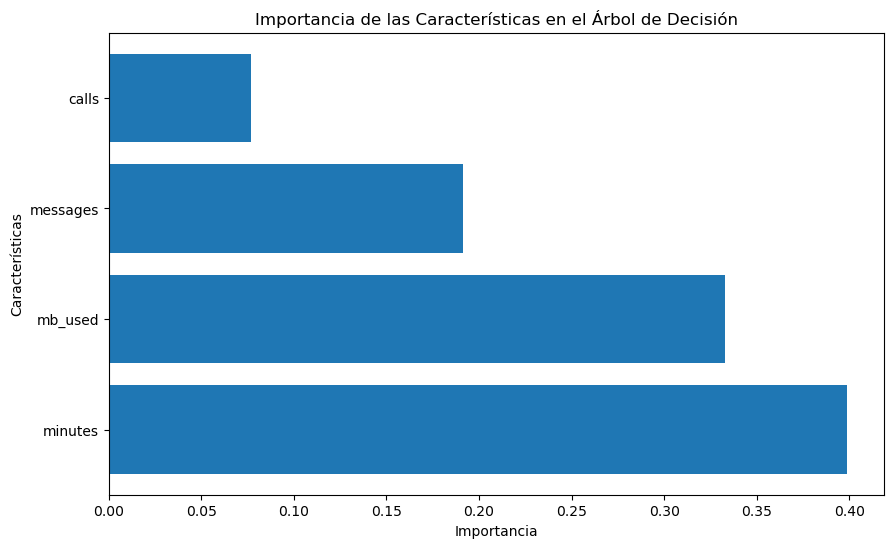

In [58]:
# Obtener la importancia de las características
importances = best_model_dt.feature_importances_

# Ordenar las importancias de mayor a menor
indices = np.argsort(importances)[::-1]

# Crear una lista con los nombres de las características
feature_names = features_train.columns

# Crear un gráfico de barras horizontal
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), feature_names[indices])

plt.xlabel('Importancia')
plt.ylabel('Características')
plt.title('Importancia de las Características en el Árbol de Decisión')
plt.show()

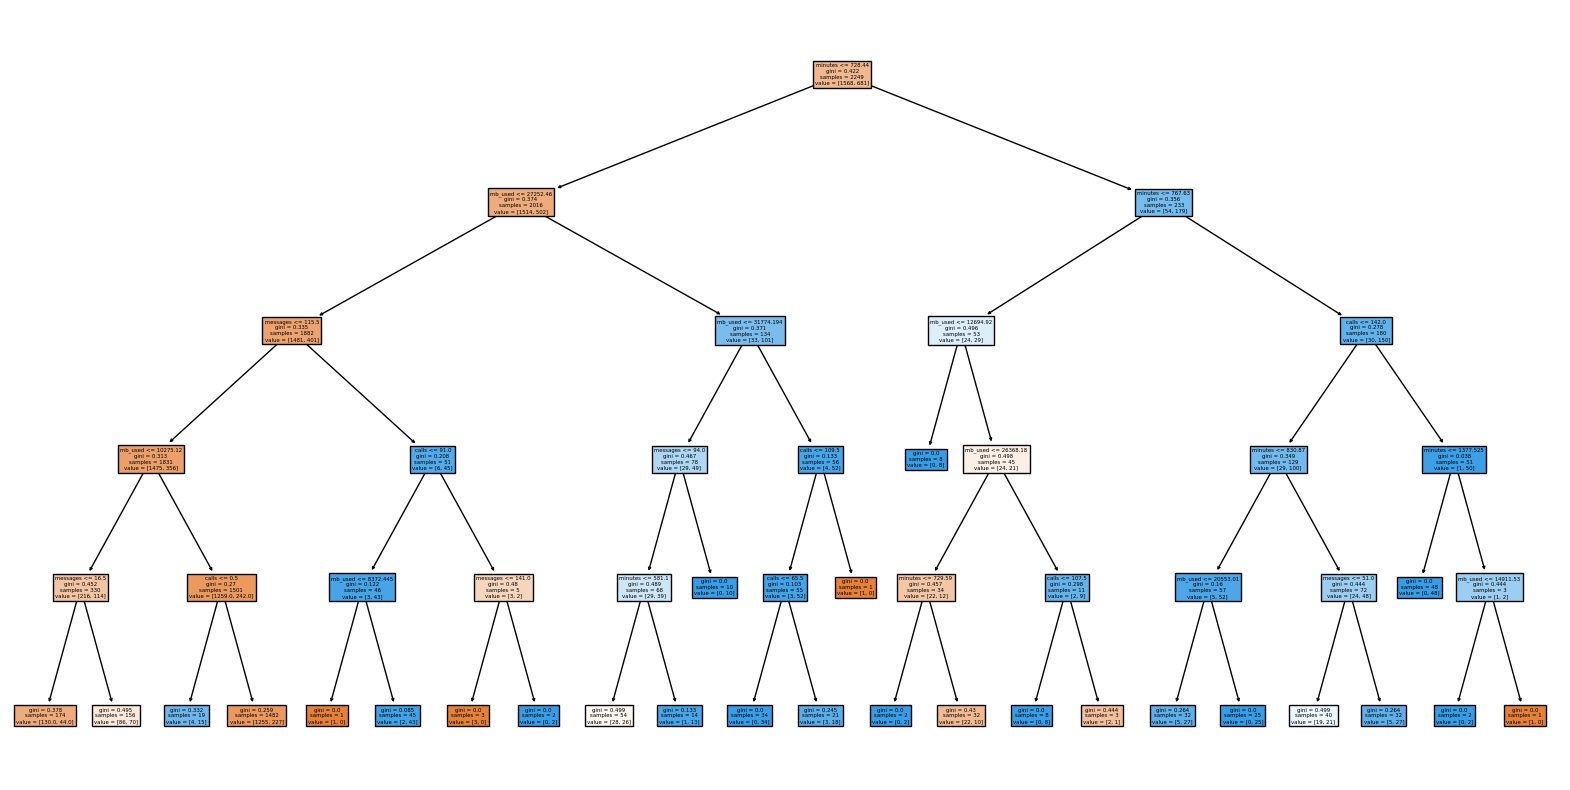

In [59]:
# Visualizar el árbol de decisión
plt.figure(figsize=(20,10))
plot_tree(best_model_dt, feature_names=feature_names, filled=True)
plt.show()

Conclusiones del modelo Arbol del decision

- Gráfico de Importancia de Características:

    - Minutes: Es la característica que más influye en la clasificación, lo que indica que la duración total de las llamadas es un factor determinante para decidir si un usuario debe estar en el plan Ultra o Smart.
    
    - mb_used: La cantidad de datos consumidos también es un factor clave, lo que sugiere que los usuarios con un alto consumo de datos son más propensos a elegir el plan Ultra.
    
    - messages: El número de mensajes de texto tiene una importancia moderada en la clasificación.
    
    - calls: El número de llamadas, aunque importante, tiene un peso menor en comparación con las otras características.

- Resultados del Modelo:

    - Mejora en la precisión: Al ajustar los hiperparámetros del árbol de decisión, se logró aumentar la precisión del modelo de 0.727 a 0.773, lo que indica que el modelo ajustado es capaz de clasificar a los usuarios con mayor exactitud.

    - Importancia de la profundidad del árbol: El parámetro max_depth se estableció en 5, lo que sugiere que una profundidad excesiva puede llevar a overfitting. Un árbol más profundo puede capturar ruido en los datos, lo que disminuye su capacidad de generalizar a nuevos datos.

    - Importancia de la muestra mínima para dividir un nodo: El parámetro min_samples_split se estableció en 2, lo que indica que se requieren al menos 2 muestras para dividir un nodo. Este parámetro ayuda a controlar el tamaño de los nodos y evita que el árbol se vuelva demasiado complejo.


## Random Forest


### Creacion y Entrenamiento del Modelo Random Forest Básico 

In [60]:
# Crear un objeto del modelo de Random Forest
modelo_rf = RandomForestClassifier(random_state=123)

# Entrenar el modelo con los datos de entrenamiento
modelo_rf.fit(features_train, target_train)


RandomForestClassifier(random_state=123)

### Evaluacion del Modelo Random Forest Básico 

In [61]:
# Hacer predicciones en el conjunto de validación
y_pred_rf = modelo_rf.predict(features_valid)

# Evaluar la precisión del modelo
accuracy_rf = accuracy_score(target_valid, y_pred_rf)
print("Precisión del modelo_rf:", accuracy_rf)

Precisión del modelo_rf: 0.8031088082901554


### Optimización de Hiperparámetros con GridSearchCV Modelo Random Forest 

In [62]:
# Definir los valores de los hiperparámetros 
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Crear el modelo base
modelo_rf = RandomForestClassifier(random_state=123)

# Crear el objeto GridSearchCV
grid_search = GridSearchCV(estimator=modelo_rf, param_grid=param_grid, cv=5, n_jobs=-1)

# Ajustar el modelo
grid_search.fit(features_train, target_train)

# Obtener los mejores parámetros
best_params_rf = grid_search.best_params_
best_model_rf = grid_search.best_estimator_

In [63]:
print(best_params_rf)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [64]:
print(best_model_rf)

RandomForestClassifier(max_depth=10, random_state=123)


### Evaluación del Modelo Modelo Random Forest Optimizado

In [65]:
# Hacer predicciones con el mejor modelo
y_pred_best_rf = best_model_rf.predict(features_valid)

# Evaluar la precisión del mejor modelo
accuracy_best_rf = accuracy_score(target_valid, y_pred_best_rf)
print("Precisión del mejor modelo_rf:", accuracy_best_rf)

Precisión del mejor modelo_rf: 0.794818652849741


### Visualización de la Importancia de las Características en Random Forest

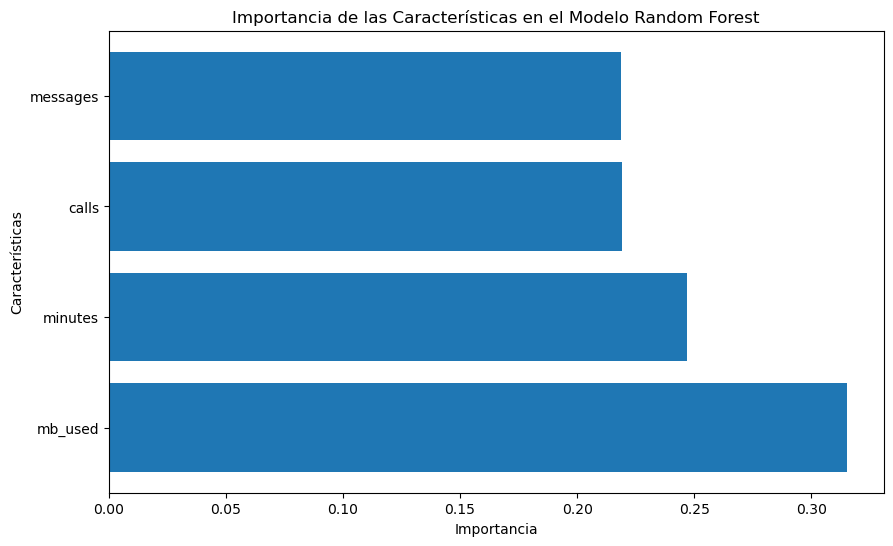

In [66]:
# Obtener la importancia de las características
importances = best_model_rf.feature_importances_

# Ordenar las importancias de mayor a menor
indices = np.argsort(importances)[::-1]

# Crear una lista con los nombres de las características
feature_names = features_train.columns

# Crear un gráfico de barras horizontal
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), feature_names[indices])

plt.xlabel('Importancia')
plt.ylabel('Características')
plt.title('Importancia de las Características en el Modelo Random Forest')
plt.show()

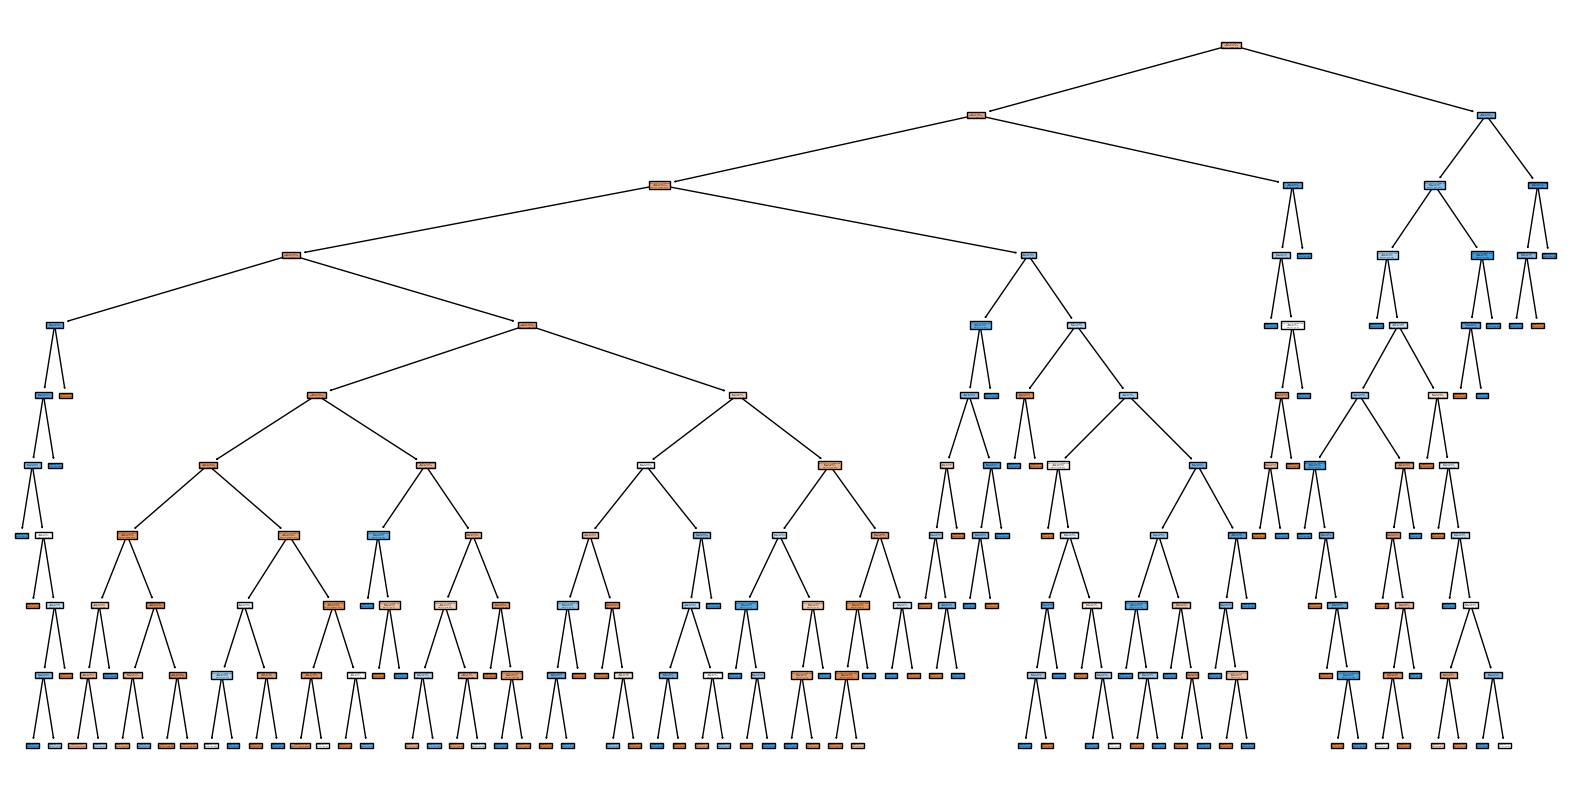

In [67]:
# Visualizar uno de los árboles del bosque
plt.figure(figsize=(20,10))
plot_tree(best_model_rf.estimators_[0], feature_names=feature_names, filled=True)
plt.show()

Conclusiones del modelo Random Forest

- Gráfico de Importancia de Características:

    - mb_used: La cantidad de datos consumidos es la característica más importante para predecir si un usuario debe estar en el plan Ultra o Smart.

    - minutes: La duración total de las llamadas también es un factor determinante, aunque con un peso ligeramente menor que en el modelo anterior.

    - messages: El número de mensajes de texto mantiene una importancia moderada en la clasificación.
    
    - calls: El número de llamadas sigue siendo la característica menos influyente.

- Resultados del Modelo:

    - Mayor precisión: El modelo de Random Forest, después de ajustar los hiperparámetros, alcanzó una precisión de 0.794, superando ligeramente al modelo de árbol de decisión. Esto indica que el Random Forest es capaz de capturar patrones más complejos en los datos y generalizar mejor.

    - Mejores hiperparámetros: Los mejores hiperparámetros encontrados fueron max_depth=10, min_samples_split=2 y n_estimators=100. Esto significa que un árbol más profundo, con nodos más pequeños y 100 árboles en el bosque, proporcionó el mejor rendimiento.

    - Estabilidad: Los bosques aleatorios son conocidos por su estabilidad y menor propensión al overfitting, lo que se confirma en los resultados obtenidos.

## Regresión Logística

### Creando y Entrenando un Modelo de Regresión Logística Básico

In [68]:
# Crear un modelo de Regresión Logística básico
modelo_lr = LogisticRegression(random_state=123)

# Entrenar el modelo con los datos de entrenamiento
modelo_lr.fit(features_train, target_train)

LogisticRegression(random_state=123)

### Evaluacion del Modelo de Regresión Logística Básico

In [69]:
# Hacer predicciones en el conjunto de validación
y_pred_lr = modelo_lr.predict(features_valid)

# Evaluar la precisión del modelo
accuracy_lr = accuracy_score(target_valid, y_pred_lr)
print("Precisión del modelo_lr:", accuracy_lr)

Precisión del modelo_lr: 0.7336787564766839


### Optimizando los Hiperparámetros con GridSearchCV Modelo de Regresión Logística

In [70]:
# Definir los valores de los hiperparámetros 
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10]
}

# Crear el modelo base
modelo_lr = LogisticRegression(random_state=12345)

# Crear el objeto GridSearchCV
grid_search = GridSearchCV(estimator=modelo_lr, param_grid=param_grid, cv=5, n_jobs=-1)

# Ajustar el modelo
grid_search.fit(features_train, target_train)

# Obtener los mejores parámetros
best_params_lr = grid_search.best_params_
best_model_lr = grid_search.best_estimator_

In [71]:
print (best_params_lr)

{'C': 0.001}


In [72]:
print(best_model_lr)

LogisticRegression(C=0.001, random_state=12345)


### Evaluando el Modelo de Regresión Logística Optimizado

In [73]:
# Hacer predicciones con el mejor modelo
y_pred_best_lr = best_model_lr.predict(features_valid)

# Evaluar la precisión del mejor modelo
accuracy_best_lr = accuracy_score(target_valid, y_pred_best_lr)
print("Precisión del mejor modelo lr:", accuracy_best_lr)

Precisión del mejor modelo lr: 0.7326424870466322


### Visualización de la Importancia de las Características en Regresión Logistica

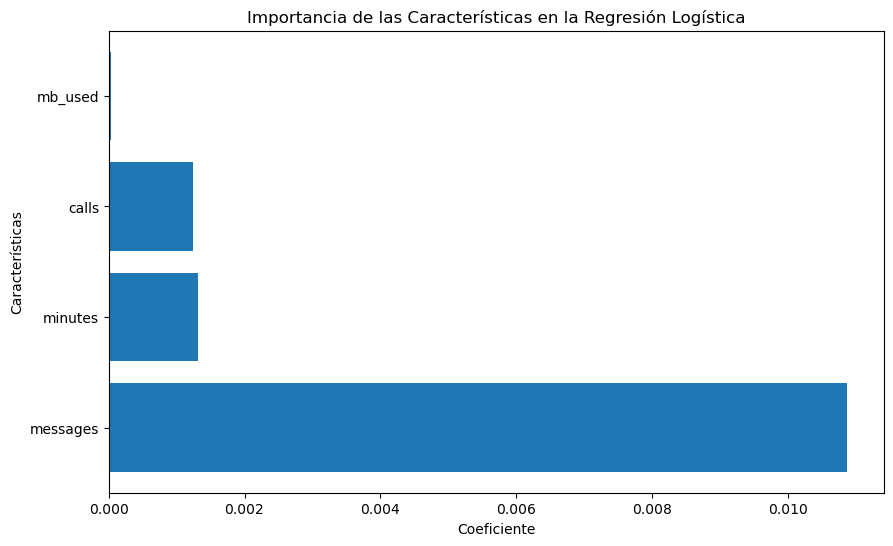

In [74]:
# Obtener los coeficientes
coefs = best_model_lr.coef_[0]

# Ordenar los coeficientes de mayor a menor
indices = np.argsort(np.abs(coefs))[::-1]

# Crear una lista con los nombres de las características
feature_names = features_train.columns

# Crear un gráfico de barras horizontal
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), coefs[indices], align='center')
plt.yticks(range(len(indices)), feature_names[indices])
plt.xlabel('Coeficiente')
plt.ylabel('Características')
plt.title('Importancia de las Características en la Regresión Logística')
plt.show()

Conclusiones del modelo Regresion Logistica

- Gráfico de Importancia de Características:

    - messages: El número de mensajes de texto es la característica que tiene un mayor impacto en la predicción. Un coeficiente más alto indica una mayor influencia de esta característica en la probabilidad de que un usuario esté en el plan Ultra.

    - minutes: La duración de las llamadas también es un factor relevante, aunque con menor influencia que los mensajes.

    - calls: El número de llamadas tiene un impacto relativamente bajo en la clasificación.

    - mb_used: En este caso, el consumo de datos no parece ser un factor determinante en la predicción, según los coeficientes obtenidos.

- Resultados del Modelo:

    - Precisión: La precisión del modelo de regresión logística, después de ajustar el hiperparámetro C, alcanzó un valor de 0.733, lo cual es razonable pero ligeramente inferior a los modelos de árbol de decisión y Random Forest.

    - Mejor hiperparámetro: El valor óptimo para el parámetro C fue 0.01. Este parámetro controla la fuerza de la regularización, y un valor más bajo indica una mayor regularización, lo que puede ayudar a prevenir el sobreajuste.

    - Coeficientes: Los coeficientes de la regresión logística indican la dirección y la magnitud del efecto de cada característica en la probabilidad de pertenecer al plan Ultra. Un coeficiente positivo indica que un aumento en el valor de esa característica aumenta la probabilidad de estar en el plan Ultra, mientras que un coeficiente negativo indica lo contrario.


# Paso 4- Calidad del modelo

## Matriz de confusión

In [75]:
def evaluar_modelo(modelo, features, target, nombre_modelo):
    y_pred = modelo.predict(features)
    print(f"Resultados para {nombre_modelo}:")
    print(classification_report(target, y_pred))


In [76]:

# Evaluar modelo Arbol de decision

evaluar_modelo(best_model_dt, features_valid, target_valid, 'Árbol de Decisión')


Resultados para Árbol de Decisión:
              precision    recall  f1-score   support

           0       0.77      0.96      0.85       661
           1       0.81      0.37      0.50       304

    accuracy                           0.77       965
   macro avg       0.79      0.66      0.68       965
weighted avg       0.78      0.77      0.74       965



El modelo tiene una precisión general bastante buena (0.77), lo que significa que acertó en la mayoría de las predicciones. Sin embargo, el recall para la clase "Ultra", es bastante bajo (0.37). Esto significa que el modelo está teniendo dificultades para identificar correctamente a los clientes que deberían estar en el plan "Ultra".

- Falsos negativos: El modelo está clasificando a muchos clientes que deberían estar en el plan "Ultra" como si estuvieran en el plan "Smart". Esto podría llevar a que algunos clientes no tengan los recursos suficientes en su plan.

- Desequilibrio de clases: Podría haber un desequilibrio en los datos, con más muestras de la clase "Smart" que de la clase "Ultra". Esto puede afectar el rendimiento del modelo y hacer que se sesgue hacia la clase mayoritaria.

In [77]:
evaluar_modelo(best_model_rf, features_valid, target_valid, 'Random Forest')


Resultados para Random Forest:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       661
           1       0.76      0.51      0.61       304

    accuracy                           0.79       965
   macro avg       0.78      0.72      0.73       965
weighted avg       0.79      0.79      0.78       965



El modelo de Random Forest tiene un F1-score de 0.86 para la clase 0 ( "Smart") y de 0.61 para la clase 1 ("Ultra"). Esto sugiere que el modelo es mejor prediciendo la clase 0 (Smart) que la clase 1 (Ultra).

- El modelo es bastante bueno para identificar a los clientes que deberían estar en el plan "Smart".

- Sin embargo, tiene dificultades para identificar correctamente a los clientes que deberían estar en el plan "Ultra". Esto podría deberse a que hay menos datos de entrenamiento para la clase "Ultra" o porque las características que distinguen a los clientes "Ultra" son más difíciles de capturar.

In [78]:
evaluar_modelo(best_model_lr, features_valid, target_valid, 'Regresión Logística')

Resultados para Regresión Logística:
              precision    recall  f1-score   support

           0       0.73      0.97      0.83       661
           1       0.78      0.21      0.33       304

    accuracy                           0.73       965
   macro avg       0.75      0.59      0.58       965
weighted avg       0.74      0.73      0.67       965



Clase 0 ("Smart"):

Alta precisión y recall: El modelo es muy bueno en identificar a los clientes que están en el plan "Smart".
F1-score alto: Indica un buen equilibrio entre precisión y recall para esta clase.

Clase 1 ("Ultra"):

Baja precisión: Cuando el modelo predice que un cliente está en el plan "Ultra", a menudo se equivoca.
Muy bajo recall: El modelo está pasando por alto muchos clientes que realmente deberían estar en el plan "Ultra".
F1-score bajo: Indica un desequilibrio entre precisión y recall, y un rendimiento general pobre para esta clase.

### Componentes de la matriz de confusión:

- Verdaderos Positivos (VP): El modelo predijo "Ultra" y el cliente realmente estaba en el plan "Ultra".
- Verdaderos Negativos (VN): El modelo predijo "Smart" y el cliente realmente estaba en el plan "Smart".
- Falsos Positivos (FP): El modelo predijo "Ultra" pero el cliente estaba en el plan "Smart".
-  Falsos Negativos (FN): El modelo predijo "Smart" pero el cliente estaba en el plan "Ultra".

In [79]:
def evaluar_modelo(modelo, features, target, nombre_modelo):
    y_pred = modelo.predict(features)
    
    # Calcular la matriz de confusión
    cm = confusion_matrix(target, y_pred)

    # Crear un DataFrame para la matriz de confusión con etiquetas claras
    df_cm = pd.DataFrame(cm, index=['Real: Negativo', 'Real: Positivo'], 
                         columns=['Predicho: Negativo', 'Predicho: Positivo'])
    
    # Imprimir la matriz de confusión con etiquetas
    print(f"Matriz de Confusión para {nombre_modelo}:")
    print(df_cm)



In [80]:

evaluar_modelo(best_model_dt, features_valid, target_valid, 'Árbol de Decisión')

Matriz de Confusión para Árbol de Decisión:
                Predicho: Negativo  Predicho: Positivo
Real: Negativo                 635                  26
Real: Positivo                 193                 111



- 635: El modelo predijo correctamente que 635 clientes estaban en el plan "Smart".
- 26: El modelo se equivocó al predecir que 26 clientes estaban en el plan "Ultra" cuando en realidad estaban en el "Smart" (falsos positivos).
- 193: El modelo se equivocó al predecir que 193 clientes estaban en el plan "Smart" cuando en realidad estaban en el "Ultra" (falsos negativos).
- 111: El modelo predijo correctamente que 111 clientes estaban en el plan "Ultra".

In [81]:
evaluar_modelo(best_model_rf, features_valid, target_valid, 'Random Forest')


Matriz de Confusión para Random Forest:
                Predicho: Negativo  Predicho: Positivo
Real: Negativo                 613                  48
Real: Positivo                 150                 154


Predicho: Negativo: El modelo predijo que el cliente debería estar en el plan "Smart".
Predicho: Positivo: El modelo predijo que el cliente debería estar en el plan "Ultra".
Real: Negativo: El cliente realmente estaba en el plan "Smart".
Real: Positivo: El cliente realmente estaba en el plan "Ultra".

- El modelo está clasificando correctamente a la mayoría de los clientes que están en el plan "Smart" (613 de 661).

- Sin embargo, todavía hay un número considerable de falsos positivos: 48 clientes que el modelo clasificó como "Ultra" cuando en realidad estaban en "Smart".

- En cuanto a los clientes "Ultra", el modelo está clasificando correctamente a 154 de ellos, pero también hay 150 falsos negativos, es decir, clientes que deberían estar en "Ultra" pero fueron clasificados como "Smart".

In [82]:

evaluar_modelo(best_model_lr, features_valid, target_valid, 'Regresión Logística')

Matriz de Confusión para Regresión Logística:
                Predicho: Negativo  Predicho: Positivo
Real: Negativo                 643                  18
Real: Positivo                 240                  64


- El modelo está clasificando correctamente a la mayoría de los clientes que están en el plan "Smart" (643 de 661). Esto indica que el modelo es bastante bueno en identificar a los clientes que pertenecen a la clase "Smart".

- Sin embargo, todavía hay un número considerable de falsos positivos: 18 clientes que el modelo clasificó como "Ultra" cuando en realidad estaban en "Smart".

- En cuanto a los clientes "Ultra", el modelo está clasificando correctamente a 65 de ellos, pero también hay 239 falsos negativos, es decir, clientes que deberían estar en "Ultra" pero fueron clasificados como "Smart".


## Paso 5 - Prueba de Cordura

¿Tiene sentido lo que el modelo está diciendo?

- Importancia de las características: El modelo considera que el consumo de datos (mb_used) es la característica más importante para predecir el plan. Esto tiene sentido, ya que, los clientes que consumen más datos probablemente necesiten el plan "Ultra".

- Matriz de confusión: ¿Hay muchos falsos positivos? Un falso positivo sería clasificar a un cliente como "Ultra" cuando en realidad debería estar en "Smart". Si hay muchos falsos positivos, estaríamos recomendando el plan más caro a clientes que no lo necesitan.

# Conclusiones

- Basándonos en los resultados obtenidos, el modelo de Random Forest parece ser la mejor opción para este proyecto.

    - Mayor precisión: Ofrece una mayor precisión general en comparación con los otros modelos.

    - Buen equilibrio entre precisión y recall: Es capaz de identificar correctamente tanto a los clientes que deberían estar en el plan "Smart" como a los que deberían estar en el plan "Ultra".

- Basándonos en los resultados y en la prueba de cordura, podemos concluir que el modelo de Random Forest es el más adecuado para predecir qué plan (Smart o Ultra) es el más adecuado para cada cliente. Este modelo puede ayudar a Megaline a ofrecer planes más personalizados y a mejorar la satisfacción del cliente.

    - Personalización: Megaline puede utilizar este modelo para ofrecer recomendaciones personalizadas a cada cliente en función de su comportamiento de uso.

    - Reducción de costos: Al asignar a los clientes al plan más adecuado, se pueden reducir los costos operativos y mejorar la rentabilidad.

    - Aumento de la satisfacción del cliente: Los clientes estarán más satisfechos si tienen un plan que se ajusta a sus necesidades.

